In [1]:
# Cell 1 — Imports + base config

import os, random
import numpy as np
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

IMG_HEIGHT = 240
IMG_WIDTH  = 240
BATCH_SIZE = 32

NUM_CLASSES = 2  # 0 = NoTumor, 1 = Tumor


2026-02-04 16:43:28.254342: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770223408.439156      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770223408.495591      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770223408.941084      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770223408.941126      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770223408.941129      55 computation_placer.cc:177] computation placer alr

In [2]:
# Cell 2 — Dataset roots + modality mapping (shared 2-channel setup)

ROOT_GLI  = "/kaggle/input/brats-classification/GLI_dataset/GLI"
ROOT_METS = "/kaggle/input/brats-classification/METS_dataset/METS"
ROOT_MEN  = "/kaggle/input/brats-classification/MEN_dataset/MEN"
ROOT_IXI  = "/kaggle/input/brats-classification/IXI_dataset/IXI"

# Tumor datasets (BraTS-style slices)
MODALITIES_TUMOR = ["t1n", "t1c", "t2w", "t2f"]

# IXI dataset slice folders (CHANGE if your IXI folders have different names)
MODALITIES_IXI = ["t1", "t2"]

# Stage-1 recommended: use only shared modalities (2 channels) to avoid missing-modality hacks
USE_SHARED_2CH = True
TUMOR_2CH = ["t1n", "t2w"]   # use these from GLI/METS/MEN
IXI_2CH   = ["t1", "t2"]     # use these from IXI


In [3]:
# Cell 3 — List PNGs sorted
def list_pngs_sorted(folder):
    if not os.path.isdir(folder):
        return []
    files = [f for f in os.listdir(folder) if f.lower().endswith(".png")]
    files.sort()
    return [os.path.join(folder, f) for f in files]

In [4]:
# Cell 4 — Build case_index with binary labels and per-modality slice paths

SOURCES = {
    "GLI":  ROOT_GLI,
    "METS": ROOT_METS,
    "MEN":  ROOT_MEN,
    "IXI":  ROOT_IXI,
}

case_index = {}

for source_name, root in SOURCES.items():
    for case_id in sorted(os.listdir(root)):
        case_path = os.path.join(root, case_id)
        if not os.path.isdir(case_path):
            continue

        # choose modalities based on dataset
        if source_name == "IXI":
            mods = MODALITIES_IXI
            binary_label = 0  # No Tumor
        else:
            mods = MODALITIES_TUMOR
            binary_label = 1  # Tumor

        per_mod_paths = {}
        for mod in mods:
            mod_path = os.path.join(case_path, mod)
            per_mod_paths[mod] = list_pngs_sorted(mod_path)

        global_case_id = f"{source_name}:{case_id}"  # avoid name collisions

        case_index[global_case_id] = {
            "source": source_name,
            "binary_label": binary_label,
            "case_dir": case_id,
            "modalities": per_mod_paths,
        }

print("Total cases indexed:", len(case_index))

# quick sanity check
example_key = next(iter(case_index.keys()))
print("Example case:", example_key)
print(" Source:", case_index[example_key]["source"])
print(" Binary label:", case_index[example_key]["binary_label"])
print(" Slice counts:", {m: len(v) for m, v in case_index[example_key]["modalities"].items()})

Total cases indexed: 2357
Example case: GLI:BraTS-GLI-00000-000
 Source: GLI
 Binary label: 1
 Slice counts: {'t1n': 10, 't1c': 10, 't2w': 10, 't2f': 10}


In [5]:
# Cell — Check IXI slice counts using a single modality

IXI_ROOT = ROOT_IXI
CHECK_MODALITY = MODALITIES_IXI[0]   # e.g. "t1"
TARGET_SLICES = 17

ixi_cases_below_target = []

for case_id in sorted(os.listdir(IXI_ROOT)):
    case_path = os.path.join(IXI_ROOT, case_id)
    if not os.path.isdir(case_path):
        continue

    mod_path = os.path.join(case_path, CHECK_MODALITY)

    if not os.path.isdir(mod_path):
        n_slices = 0
    else:
        n_slices = len([f for f in os.listdir(mod_path) if f.lower().endswith(".png")])

    if n_slices < TARGET_SLICES:
        ixi_cases_below_target.append((case_id, n_slices))

print(f"Total IXI cases: {len([d for d in os.listdir(IXI_ROOT) if os.path.isdir(os.path.join(IXI_ROOT, d))])}")
print(f"IXI cases with < {TARGET_SLICES} slices in '{CHECK_MODALITY}': {len(ixi_cases_below_target)}\n")

print("Examples (case_id : slice count):")
for cid, n in ixi_cases_below_target[:10]:
    print(f"{cid}: {n} slices")

# Minimum slice count observed
if ixi_cases_below_target:
    min_slices = min(n for _, n in ixi_cases_below_target)
else:
    min_slices = TARGET_SLICES

print(f"\nMinimum slices observed in '{CHECK_MODALITY}': {min_slices}")


Total IXI cases: 577
IXI cases with < 17 slices in 't1': 0

Examples (case_id : slice count):

Minimum slices observed in 't1': 17


In [6]:
# Cell 5 — QC rules and slice planning per case

# Per-source rules: minimum slices per modality, and target slices per modality
# (Adjust IXI target to match your intended no-tumor slice count per case)
SOURCE_RULES = {
    "GLI":  {"min": 8, "target": 10},
    "METS": {"min": 9, "target": 16},
    "MEN":  {"min": 8, "target": 16},
    "IXI":  {"min": 8, "target": 17},
}

def build_slice_plan_for_case(entry):
    src = entry["source"]
    rules = SOURCE_RULES[src]
    min_req = rules["min"]
    target = rules["target"]

    planned = {}

    for mod, paths in entry["modalities"].items():
        n = len(paths)

        # QC: too few slices in this modality => drop case
        if n < min_req:
            return False, {}

        # exact target => take all indices
        if n == target:
            planned[mod] = list(range(n))

        # more than target => central crop (safety)
        elif n > target:
            start = (n - target) // 2
            planned[mod] = list(range(start, start + target))

        # between min and target => duplicate cyclically to reach target
        else:
            reps = (target + n - 1) // n  # ceil(target / n)
            idxs = (list(range(n)) * reps)[:target]
            planned[mod] = idxs

    return True, planned


In [7]:
# Cell 6 — Apply QC and build clean_case_index

clean_case_index = {}
dropped_cases = []

for case_key, entry in case_index.items():
    keep, plan = build_slice_plan_for_case(entry)
    if not keep:
        dropped_cases.append(case_key)
        continue

    new_entry = dict(entry)
    new_entry["slice_plan"] = plan
    clean_case_index[case_key] = new_entry

print("Total original cases:", len(case_index))
print("Cases kept after QC:", len(clean_case_index))
print("Cases dropped:", len(dropped_cases))

# Counts per source after QC
counts_by_source = {}
for e in clean_case_index.values():
    src = e["source"]
    counts_by_source[src] = counts_by_source.get(src, 0) + 1

print("\nCases per source after QC:")
for src in sorted(counts_by_source.keys()):
    print(f"  {src}: {counts_by_source[src]}")

# Optional: show a few dropped cases
print("\nFirst 10 dropped cases:")
for c in dropped_cases[:10]:
    print(" ", c)

Total original cases: 2357
Cases kept after QC: 2290
Cases dropped: 67

Cases per source after QC:
  GLI: 1239
  IXI: 577
  MEN: 199
  METS: 275

First 10 dropped cases:
  GLI:BraTS-GLI-00441-000
  GLI:BraTS-GLI-00705-000
  GLI:BraTS-GLI-01119-000
  GLI:BraTS-GLI-01137-000
  GLI:BraTS-GLI-01273-000
  GLI:BraTS-GLI-01344-000
  GLI:BraTS-GLI-01363-000
  GLI:BraTS-GLI-01500-000
  METS:BraTS-MET-00026-000
  METS:BraTS-MET-00108-000


In [8]:
# Cell 7 — Build slice_samples (binary task)

slice_samples = []  # (case_key, local_idx, y, source)

for case_key, entry in clean_case_index.items():
    y = entry["binary_label"]
    src = entry["source"]

    # planned number of slices (same length across modalities after planning)
    any_mod = next(iter(entry["slice_plan"].keys()))
    num_slices = len(entry["slice_plan"][any_mod])

    for local_idx in range(num_slices):
        slice_samples.append((case_key, local_idx, y, src))

print("Total slice-level samples:", len(slice_samples))

# quick binary slice counts
counts_bin = {0: 0, 1: 0}
for _, _, y, _ in slice_samples:
    counts_bin[y] += 1

print("Slice counts (0=NoTumor, 1=Tumor):", counts_bin)

Total slice-level samples: 29783
Slice counts (0=NoTumor, 1=Tumor): {0: 9809, 1: 19974}


In [9]:
# Cell 8 — Case-level stratified split by SOURCE (GLI/METS/MEN/IXI)

case_ids = []
strat_labels = []  # stratify by source to preserve tumor-subtype proportions too

for case_key, entry in clean_case_index.items():
    case_ids.append(case_key)
    strat_labels.append(entry["source"])  # "GLI", "METS", "MEN", "IXI"

# 70% train, 30% temp
train_case_ids, temp_case_ids, train_strat, temp_strat = train_test_split(
    case_ids,
    strat_labels,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=strat_labels,
)

# temp -> 15% val, 15% test
val_case_ids, test_case_ids, val_strat, test_strat = train_test_split(
    temp_case_ids,
    temp_strat,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=temp_strat,
)

train_cases = set(train_case_ids)
val_cases   = set(val_case_ids)
test_cases  = set(test_case_ids)

print("Case counts:")
print("  Train:", len(train_cases))
print("  Val  :", len(val_cases))
print("  Test :", len(test_cases))
print("  Total:", len(train_cases) + len(val_cases) + len(test_cases))

def count_cases_by_source(case_set):
    counts = {}
    for cid in case_set:
        src = clean_case_index[cid]["source"]
        counts[src] = counts.get(src, 0) + 1
    return counts

print("\nCase counts by source:")
print("  Train:", count_cases_by_source(train_cases))
print("  Val  :", count_cases_by_source(val_cases))
print("  Test :", count_cases_by_source(test_cases))

# Safety check: no overlap
print("\nOverlap check:")
print("  Train∩Val :", len(train_cases & val_cases))
print("  Train∩Test:", len(train_cases & test_cases))
print("  Val∩Test  :", len(val_cases & test_cases))


Case counts:
  Train: 1603
  Val  : 343
  Test : 344
  Total: 2290

Case counts by source:
  Train: {'GLI': 867, 'IXI': 404, 'MEN': 139, 'METS': 193}
  Val  : {'GLI': 186, 'METS': 41, 'IXI': 86, 'MEN': 30}
  Test : {'MEN': 30, 'GLI': 186, 'IXI': 87, 'METS': 41}

Overlap check:
  Train∩Val : 0
  Train∩Test: 0
  Val∩Test  : 0


In [10]:
# Cell 9 — Map slice_samples to splits

train_slices = []
val_slices = []
test_slices = []

for (case_key, local_idx, y, src) in slice_samples:
    if case_key in train_cases:
        train_slices.append((case_key, local_idx, y, src))
    elif case_key in val_cases:
        val_slices.append((case_key, local_idx, y, src))
    elif case_key in test_cases:
        test_slices.append((case_key, local_idx, y, src))
    else:
        raise ValueError("Case not found in any split: " + case_key)

def count_slices_binary(samples):
    c = {0: 0, 1: 0}
    for _, _, y, _ in samples:
        c[y] += 1
    return c

def count_slices_by_source(samples):
    c = {}
    for _, _, _, src in samples:
        c[src] = c.get(src, 0) + 1
    return c

print("Slice counts (total):")
print("  Train:", len(train_slices))
print("  Val  :", len(val_slices))
print("  Test :", len(test_slices))
print("  Total:", len(train_slices) + len(val_slices) + len(test_slices))

print("\nSlice counts by binary label (0=NoTumor, 1=Tumor):")
print("  Train:", count_slices_binary(train_slices))
print("  Val  :", count_slices_binary(val_slices))
print("  Test :", count_slices_binary(test_slices))

print("\nSlice counts by source (GLI/METS/MEN/IXI):")
print("  Train:", count_slices_by_source(train_slices))
print("  Val  :", count_slices_by_source(val_slices))
print("  Test :", count_slices_by_source(test_slices))


Slice counts (total):
  Train: 20850
  Val  : 4458
  Test : 4475
  Total: 29783

Slice counts by binary label (0=NoTumor, 1=Tumor):
  Train: {0: 6868, 1: 13982}
  Val  : {0: 1462, 1: 2996}
  Test : {0: 1479, 1: 2996}

Slice counts by source (GLI/METS/MEN/IXI):
  Train: {'GLI': 8670, 'METS': 3088, 'MEN': 2224, 'IXI': 6868}
  Val  : {'GLI': 1860, 'METS': 656, 'MEN': 480, 'IXI': 1462}
  Test : {'GLI': 1860, 'METS': 656, 'MEN': 480, 'IXI': 1479}


In [11]:
# Cell 10 — Optional: oversample the training set to balance Tumor vs NoTumor

def count_binary(samples):
    c = {0: 0, 1: 0}
    for _, _, y, _ in samples:
        c[y] += 1
    return c

print("Original train binary counts:", count_binary(train_slices))

do_oversample_train = True

if do_oversample_train:
    train_by_y = {0: [], 1: []}
    for s in train_slices:
        train_by_y[s[2]].append(s)

    n0 = len(train_by_y[0])
    n1 = len(train_by_y[1])
    target = max(n0, n1)

    balanced_train_slices = []
    for y in [0, 1]:
        base = list(train_by_y[y])
        if len(base) == 0:
            continue

        # include all originals
        balanced = base[:]

        # add more with replacement if needed
        if len(base) < target:
            extra = target - len(base)
            balanced.extend(random.choices(base, k=extra))

        balanced_train_slices.extend(balanced)

    random.shuffle(balanced_train_slices)

else:
    balanced_train_slices = train_slices

print("Balanced train binary counts:", count_binary(balanced_train_slices))
print("Total balanced train slices:", len(balanced_train_slices))


Original train binary counts: {0: 6868, 1: 13982}
Balanced train binary counts: {0: 13982, 1: 13982}
Total balanced train slices: 27964


In [12]:
# Cell 11 — Keras Sequence for Stage-1 (binary) using shared 2-channel input

class TumorNoTumorSequence(Sequence):
    def __init__(self, samples, case_index, batch_size=32, shuffle=True):
        self.samples = list(samples)   # (case_key, local_idx, y, source)
        self.case_index = case_index
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.indices) / float(self.batch_size)))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.samples))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_samples = [self.samples[i] for i in batch_idx]

        # 2-channel input
        batch_x = np.zeros((len(batch_samples), IMG_HEIGHT, IMG_WIDTH, 2), dtype=np.float32)
        batch_y = np.zeros((len(batch_samples),), dtype=np.int32)

        for i, (case_key, local_idx, y, source) in enumerate(batch_samples):
            entry = self.case_index[case_key]
            plan = entry["slice_plan"]

            # modality mapping for Stage-1
            if source == "IXI":
                mods = IXI_2CH     # ["t1","t2"]
            else:
                mods = TUMOR_2CH   # ["t1n","t2w"]

            channels = []
            for mod in mods:
                paths = entry["modalities"][mod]
                idx_list = plan[mod]
                real_idx = idx_list[local_idx]
                img_path = paths[real_idx]

                img = load_img(img_path, color_mode="grayscale",
                               target_size=(IMG_HEIGHT, IMG_WIDTH))
                arr = img_to_array(img)[:, :, 0].astype("float32") / 255.0
                channels.append(arr)

            batch_x[i] = np.stack(channels, axis=-1)  # (H,W,2)
            batch_y[i] = y

        batch_y_cat = to_categorical(batch_y, num_classes=NUM_CLASSES)
        return batch_x, batch_y_cat


train_gen = TumorNoTumorSequence(balanced_train_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = TumorNoTumorSequence(val_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=False)
test_gen  = TumorNoTumorSequence(test_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=False)

# sanity check
x_batch, y_batch = train_gen[0]
print("Train batch X shape:", x_batch.shape)  # (bs,240,240,2)
print("Train batch Y shape:", y_batch.shape)  # (bs,2)
print("X min/max:", x_batch.min(), x_batch.max())


Train batch X shape: (32, 240, 240, 2)
Train batch Y shape: (32, 2)
X min/max: 0.0 1.0


In [13]:
# Cell 12 — Generator verification utilities

def decode_one_hot(y_cat):
    return np.argmax(y_cat, axis=1)

# 1) Check a few batches: shapes + class balance in batches
for b in [0, 1, 2]:
    xb, yb = train_gen[b]
    y_int = decode_one_hot(yb)
    print(f"Batch {b}: X={xb.shape}, y counts -> NoTumor={np.sum(y_int==0)}, Tumor={np.sum(y_int==1)}")

# 2) Print a few sample paths to confirm modality mapping is correct
#    We'll search inside the generator samples list directly.
print("\nSample path sanity check (first 6 samples):")
for i in range(6):
    case_key, local_idx, y, source = train_gen.samples[i]
    entry = clean_case_index[case_key]
    plan = entry["slice_plan"]

    if source == "IXI":
        mods = IXI_2CH
    else:
        mods = TUMOR_2CH

    print(f"\n{i}) case={case_key} source={source} y={y} local_idx={local_idx} mods={mods}")
    for mod in mods:
        paths = entry["modalities"][mod]
        real_idx = plan[mod][local_idx]
        print(f"   {mod}: idx={real_idx} path={paths[real_idx]}")

# 3) Confirm that train/val/test use disjoint cases (extra safety check)
train_case_set = set([c for c, _, _, _ in train_gen.samples])
val_case_set   = set([c for c, _, _, _ in val_gen.samples])
test_case_set  = set([c for c, _, _, _ in test_gen.samples])

print("\nExtra overlap check:")
print("Train∩Val :", len(train_case_set & val_case_set))
print("Train∩Test:", len(train_case_set & test_case_set))
print("Val∩Test  :", len(val_case_set & test_case_set))

Batch 0: X=(32, 240, 240, 2), y counts -> NoTumor=18, Tumor=14
Batch 1: X=(32, 240, 240, 2), y counts -> NoTumor=18, Tumor=14
Batch 2: X=(32, 240, 240, 2), y counts -> NoTumor=18, Tumor=14

Sample path sanity check (first 6 samples):

0) case=IXI:IXI131-HH-1527 source=IXI y=0 local_idx=6 mods=['t1', 't2']
   t1: idx=6 path=/kaggle/input/brats-classification/IXI_dataset/IXI/IXI131-HH-1527/t1/IXI131-HH-1527_z125_t1.png
   t2: idx=6 path=/kaggle/input/brats-classification/IXI_dataset/IXI/IXI131-HH-1527/t2/IXI131-HH-1527_z125_t2.png

1) case=GLI:BraTS-GLI-00556-000 source=GLI y=1 local_idx=2 mods=['t1n', 't2w']
   t1n: idx=2 path=/kaggle/input/brats-classification/GLI_dataset/GLI/BraTS-GLI-00556-000/t1n/BraTS-GLI-00556-000_z075_t1n.png
   t2w: idx=2 path=/kaggle/input/brats-classification/GLI_dataset/GLI/BraTS-GLI-00556-000/t2w/BraTS-GLI-00556-000_z075_t2w.png

2) case=IXI:IXI278-HH-1771 source=IXI y=0 local_idx=6 mods=['t1', 't2']
   t1: idx=6 path=/kaggle/input/brats-classification/IXI_d

# Model training EfficentNETB0

In [16]:
# Cell 1 — Imports
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

IMG_HEIGHT = 240
IMG_WIDTH = 240
NUM_CLASSES = 2  # Binary: 0=NoTumor, 1=Tumor

def build_effnetb0_2ch_binary(input_shape=(IMG_HEIGHT, IMG_WIDTH, 2),
                              train_base=False,
                              dropout1=0.4,
                              dropout2=0.3):
    """
    EfficientNetB0 adapted for 2-channel MRI input (T1 + T2) with binary output.
    Uses a learned 1x1 conv adapter (2->3) to enable ImageNet weights.
    """

    inp = layers.Input(shape=input_shape, name="input_2ch")

    # 2→3 channel adapter (learned 1×1 convolution)
    x = layers.Conv2D(3, (1, 1), padding="same", name="adapter_2to3")(inp)

    # EfficientNet preprocess expects [0,255] then uses its own normalization
    x = layers.Lambda(lambda t: t * 255.0, name="to_255")(x)
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    # Load EfficientNetB0 pretrained on ImageNet
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )
    base.trainable = train_base  # Frozen for Stage 0

    feat = base(x)

    # Classification head
    h = layers.GlobalAveragePooling2D(name="gap")(feat)
    h = layers.Dropout(dropout1, name="drop1")(h)
    h = layers.Dense(256, activation="relu", name="fc1")(h)
    h = layers.Dropout(dropout2, name="drop2")(h)
    out = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(h)

    model = Model(inputs=inp, outputs=out, name="EffNetB0_2ch_binary")
    return model

# Build the model (backbone frozen)
model_eff = build_effnetb0_2ch_binary(train_base=False)

print("✅ EfficientNetB0 model created successfully!")
model_eff.summary()


I0000 00:00:1770215438.278993      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB0 model created successfully!


Model: "EffNetB0_2ch_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_2ch (InputLayer)          │ (None, 240, 240, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_2to3 (Conv2D)           │ (None, 240, 240, 3)    │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_255 (Lambda)                 │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,030 (16.70 MB)

 Trainable params: 328,459 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
# Cell 2 — Compile
multi_auc = tf.keras.metrics.AUC(
    multi_label=True,
    num_labels=NUM_CLASSES,
    name="auc"
)

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model compiled with Adam (lr=1e-4), categorical_crossentropy, and AUC metric")


✅ Model compiled with Adam (lr=1e-4), categorical_crossentropy, and AUC metric


In [18]:
# Cell 3 — Sanity check
xb, yb = train_gen[0]
print("Input batch shape:", xb.shape, "| Range:", xb.min(), "-", xb.max())
print("Label batch shape:", yb.shape, "| Classes in batch:", sorted(set(yb.argmax(axis=1))))

pred = model_eff(xb[:2])
print("Prediction shape:", pred.shape)
print("Prediction row sums (should be ~1.0):", tf.reduce_sum(pred, axis=1).numpy())


Input batch shape: (32, 240, 240, 2) | Range: 0.0 - 1.0
Label batch shape: (32, 2) | Classes in batch: [np.int64(0), np.int64(1)]


I0000 00:00:1770215451.993071      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Prediction shape: (2, 2)
Prediction row sums (should be ~1.0): [1. 1.]


In [19]:
# Cell 4 — Setup callbacks for Stage 0
EPOCHS_STAGE0 = 25
ckpt_path_stage0 = "effnetb0_binary_stage0_best.keras"

callbacks_stage0 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_stage0,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks configured for Stage 0")


✅ Callbacks configured for Stage 0


In [20]:
# Cell 5 — Train Stage 0
print("🚀 Starting Stage 0 training (frozen EfficientNet backbone)...")
print("   Training only: adapter (2→3) + classification head")
print(f"   Epochs: {EPOCHS_STAGE0}")
print("   Learning rate: 1e-4\n")

history_stage0 = model_eff.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE0,
    callbacks=callbacks_stage0,
    verbose=1
)

print("\n✅ Stage 0 training complete!")


🚀 Starting Stage 0 training (frozen EfficientNet backbone)...
   Training only: adapter (2→3) + classification head
   Epochs: 25
   Learning rate: 1e-4



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1770215471.485689     125 service.cc:152] XLA service 0x7d4ab0002e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770215471.485733     125 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770215489.317367     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9012 - auc: 0.9591 - loss: 0.2318
Epoch 1: val_auc improved from -inf to 0.99872, saving model to effnetb0_binary_stage0_best.keras
874/874 ━━━━━━━━━━━━━━━━━━━━ 438s 467ms/step - accuracy: 0.9012 - auc: 0.9591 - loss: 0.2316 - val_accuracy: 0.9834 - val_auc: 0.9987 - val_loss: 0.0575 - learning_rate: 1.0000e-04
Epoch 2/25
874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9838 - auc: 0.9980 - loss: 0.0472
Epoch 2: val_auc improved from 0.99872 to 0.99952, saving model to effnetb0_binary_stage0_best.keras
874/874 ━━━━━━━━━━━━━━━━━━━━ 114s 130ms/step - accuracy: 0.9838 - auc: 0.9981 - loss: 0.0472 - val_accuracy: 0.9879 - val_auc: 0.9995 - val_loss: 0.0324 - learning_rate: 1.0000e-04
Epoch 3/25
874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9886 - auc: 0.9990 - loss: 0.0337
Epoch 3: val_auc improved from 0.99952 to 0.99956, saving model to effnetb0_binary_stage0_best.keras
874/874 ━━━━━━━━━━━━━━━━━━━━ 116s 133ms/ste

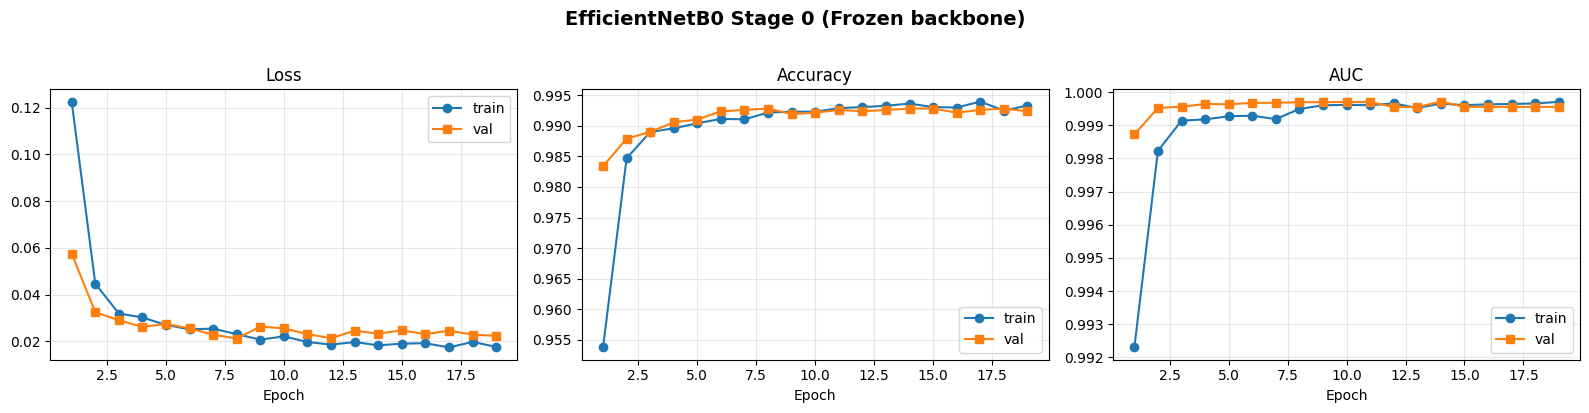

In [21]:
# Cell 6 — Plot training curves (reuse your function)
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_stage0, "EfficientNetB0 Stage 0 (Frozen backbone)")


In [22]:
# Cell 7 — Evaluation utilities (same as yours)
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["NoTumor", "Tumor"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar_kws={'label': 'Proportion' if normalize else 'Count'}
    )
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl, src) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl, src) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=2):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(
        lambda s: majority_vote(s.values, n_classes=2)
    )
    y_true_case = y_pred_case.index.to_series().apply(
        lambda ck: clean_case_index[ck]["binary_label"]
    )
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)


📊 EVALUATION: STAGE 0 (Frozen EfficientNetB0 Backbone)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 537ms/step

🔹 SLICE-LEVEL RESULTS (Stage 0)
Accuracy: 99.58%

              precision    recall  f1-score   support

     NoTumor     0.9913    0.9959    0.9936      1479
       Tumor     0.9980    0.9957    0.9968      2996

    accuracy                         0.9958      4475
   macro avg     0.9946    0.9958    0.9952      4475
weighted avg     0.9958    0.9958    0.9958      4475



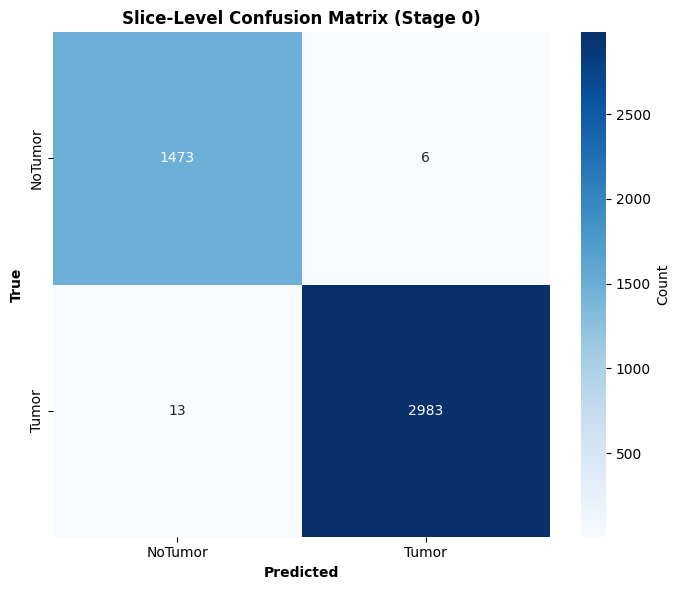

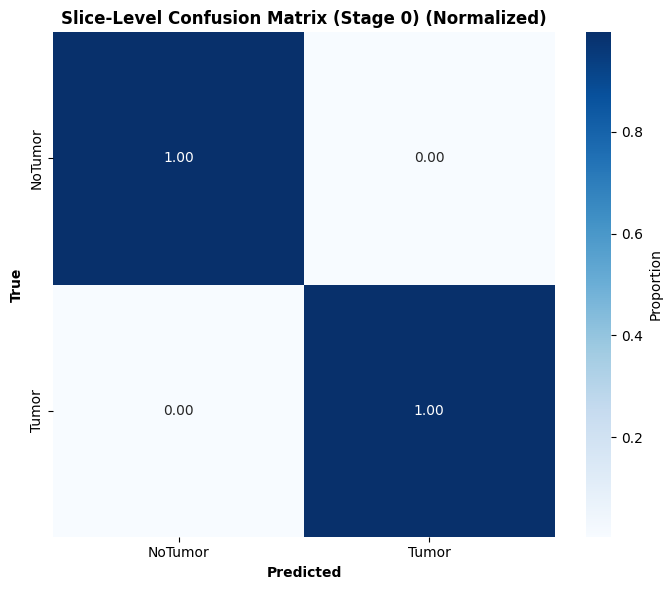


🔹 CASE-LEVEL RESULTS (Majority Voting - Stage 0)
Accuracy: 99.71%

              precision    recall  f1-score   support

     NoTumor     0.9886    1.0000    0.9943        87
       Tumor     1.0000    0.9961    0.9981       257

    accuracy                         0.9971       344
   macro avg     0.9943    0.9981    0.9962       344
weighted avg     0.9971    0.9971    0.9971       344



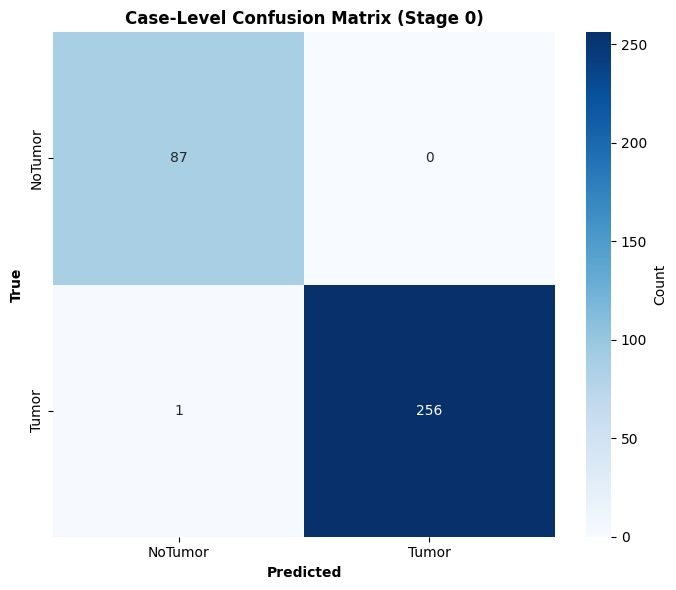

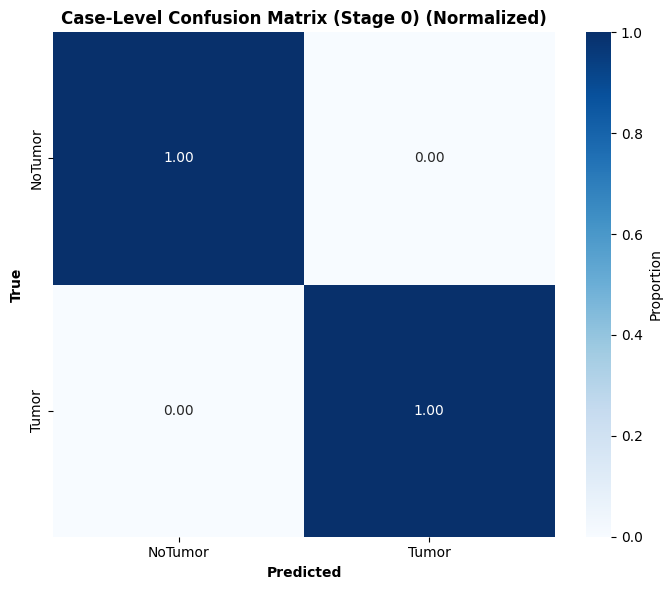

In [23]:
# Cell 8 — Evaluate Stage 0
print("=" * 70)
print("📊 EVALUATION: STAGE 0 (Frozen EfficientNetB0 Backbone)")
print("=" * 70)

y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_eff, test_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (Stage 0)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 0)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 0)", normalize=True)

y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (Majority Voting - Stage 0)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 0)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 0)", normalize=True)


# Fine-tuning (EfficientNet style)

In [ ]:
# Cell 9 — Load best Stage 0 model
import os
import keras

keras.config.enable_unsafe_deserialization()

multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

model_eff = keras.models.load_model(
    "effnetb0_binary_stage0_best.keras",
    custom_objects={"auc": multi_auc}
)

print("✅ EfficientNetB0 Stage 0 model loaded successfully!")


In [ ]:
# Cell 10 — Find EfficientNet base model inside the full model
def find_effnet_base(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
            return layer

    # fallback: pick the largest nested model
    candidates = [l for l in model.layers if isinstance(l, tf.keras.Model)]
    if candidates:
        return max(candidates, key=lambda m: len(m.layers))

    raise ValueError("Could not find EfficientNet base model")

eff_base = find_effnet_base(model_eff)
print(f"✅ Found EfficientNet base: {eff_base.name}")
print(f"   Total layers in base: {len(eff_base.layers)}")


In [ ]:
# Cell 11 — Fine-tuning Stage 1: unfreeze last N layers
N_UNFREEZE = 30

# freeze all base layers
for layer in eff_base.layers:
    layer.trainable = False

# unfreeze last N layers
for layer in eff_base.layers[-N_UNFREEZE:]:
    layer.trainable = True

unfrozen = [l.name for l in eff_base.layers if l.trainable]
print(f"✅ Stage 1: Unfrozen last {N_UNFREEZE} layers")
print("   First few unfrozen:", unfrozen[:5])
print("   Last few unfrozen :", unfrozen[-5:])

trainable_count = sum([tf.size(w).numpy() for w in model_eff.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_eff.non_trainable_weights])
print(f"\n📊 Trainable params: {trainable_count:,}")
print(f"📊 Non-trainable params: {non_trainable_count:,}")


In [ ]:
# Cell 12 — Recompile with lower LR (Fine-tuning Stage 1)
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Recompiled with LR=1e-5 for Fine-tuning Stage 1")


In [ ]:
# Cell 13 — Train Fine-tuning Stage 1
EPOCHS_FT_STAGE1 = 20
ckpt_path_ft1 = "effnetb0_binary_finetune_stage1_best.keras"

callbacks_ft1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=3,
        min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_ft1, monitor="val_auc", mode="max",
        save_best_only=True, verbose=1
    )
]

print("🚀 Starting Fine-tuning Stage 1 (last layers unfrozen)...")
print(f"   Epochs: {EPOCHS_FT_STAGE1}")
print(f"   Learning rate: 1e-5\n")

history_ft_stage1 = model_eff.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT_STAGE1,
    callbacks=callbacks_ft1,
    verbose=1
)

print("\n✅ Fine-tuning Stage 1 complete!")
plot_history(history_ft_stage1, "EffNetB0 Fine-tuning Stage 1 (last layers)")


In [ ]:
# Cell 14 — Evaluate Fine-tuning Stage 1
print("=" * 70)
print("📊 EVALUATION: FINE-TUNING STAGE 1 (EffNetB0 last layers unfrozen)")
print("=" * 70)

y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_eff, test_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (FT Stage 1)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 1)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 1)", normalize=True)

y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (FT Stage 1, Voting)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 1)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 1)", normalize=True)


# CNN building

In [19]:
# Cell 11 — Custom CNN blocks (stages)

def conv_stage(x, filters, blocks, dropout=0.0, name="stage"):
    for b in range(blocks):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv{b+1}")(x)
        x = layers.BatchNormalization(name=f"{name}_bn{b+1}")(x)
        x = layers.Activation("relu", name=f"{name}_relu{b+1}")(x)
        if dropout > 0:
            x = layers.Dropout(dropout, name=f"{name}_drop{b+1}")(x)
    x = layers.MaxPooling2D(pool_size=2, name=f"{name}_pool")(x)
    return x


In [20]:
# Cell 12 — Build Custom CNN (2-class softmax)

def build_custom_cnn(input_shape=(240, 240, 2), base_filters=32):
    inp = layers.Input(shape=input_shape, name="input")

    x = conv_stage(inp, base_filters,     blocks=2, dropout=0.05, name="stage1")
    x = conv_stage(x,   base_filters*2,   blocks=2, dropout=0.10, name="stage2")
    x = conv_stage(x,   base_filters*4,   blocks=3, dropout=0.15, name="stage3")
    x = conv_stage(x,   base_filters*8,   blocks=3, dropout=0.20, name="stage4")

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(256, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.4, name="head_drop1")(x)
    x = layers.Dense(64, activation="relu", name="dense2")(x)
    x = layers.Dropout(0.2, name="head_drop2")(x)

    out = layers.Dense(2, activation="softmax", name="softmax")(x)

    return models.Model(inp, out, name="CustomCNN_TumorVsNoTumor")

model = build_custom_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 2), base_filters=32)
model.summary()


Model: "CustomCNN_TumorVsNoTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 240, 240, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_conv1 (Conv2D)           │ (None, 240, 240, 32)   │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_bn1 (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_relu1 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_drop1 (Dropout)          │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_conv2 (Conv2D)           │ (None, 240, 240, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_bn2 (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_relu2 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_drop2 (Dropout)          │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_pool (MaxPooling2D)      │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_conv1 (Conv2D)           │ (None, 120, 120, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_bn1 (BatchNormalization) │ (None, 120, 120, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_relu1 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_drop1 (Dropout)          │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_conv2 (Conv2D)           │ (None, 120, 120, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_bn2 (BatchNormalization) │ (None, 120, 120, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_relu2 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_drop2 (Dropout)          │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_pool (MaxPooling2D)      │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_conv1 (Conv2D)           │ (None, 60, 60, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_bn1 (BatchNormalization) │ (None, 60, 60, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_relu1 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_drop1 (Dropout)          │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_conv2 (Conv2D)           │ (None, 60, 60, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_bn2 (BatchNormalization) │ (None, 60, 60, 128)    │           51

 Total params: 1,996,034 (7.61 MB)

 Trainable params: 1,993,346 (7.60 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [21]:
# Cell 13 — Compile (softmax + categorical CE)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)


In [22]:
# Cell 14 — Callbacks

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "custom_cnn_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]


In [23]:
# Cell 15 — Train

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20


I0000 00:00:1770224250.472251     130 service.cc:152] XLA service 0x79afc0112b50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770224250.472301     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770224251.648174     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770224270.024200     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - acc: 0.9463 - auc: 0.9822 - loss: 0.1288
Epoch 1: val_auc improved from -inf to 0.40684, saving model to custom_cnn_best.keras
874/874 ━━━━━━━━━━━━━━━━━━━━ 371s 395ms/step - acc: 0.9463 - auc: 0.9823 - loss: 0.1288 - val_acc: 0.3652 - val_auc: 0.4068 - val_loss: 2.8631 - learning_rate: 1.0000e-04
Epoch 2/20
874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.9954 - auc: 0.9996 - loss: 0.0149
Epoch 2: val_auc improved from 0.40684 to 0.98862, saving model to custom_cnn_best.keras
874/874 ━━━━━━━━━━━━━━━━━━━━ 112s 128ms/step - acc: 0.9954 - auc: 0.9996 - loss: 0.0149 - val_acc: 0.9242 - val_auc: 0.9886 - val_loss: 0.1262 - learning_rate: 1.0000e-04
Epoch 3/20
874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 0.9973 - auc: 0.9997 - loss: 0.0085
Epoch 3: val_auc improved from 0.98862 to 0.99549, saving model to custom_cnn_best.keras
874/874 ━━━━━━━━━━━━━━━━━━━━ 111s 127ms/step - acc: 0.9973 - auc: 0.9997 - loss: 0.0085 - val_acc: 0.9908 - val_au

In [24]:
# Cell 16 — Evaluation utilities (softmax style like yours)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar_kws={'label': 'Proportion' if normalize else 'Count'}
    )
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)                 # (N,2)
    y_pred = np.argmax(y_prob, axis=1).astype(int)         # (N,)
    y_true = np.array([lbl for (ck, local_idx, lbl, src) in gen.samples], dtype=np.int32)
    case_keys = [ck for (ck, local_idx, lbl, src) in gen.samples]
    tumor_prob = y_prob[:, 1]
    return y_true, y_pred, tumor_prob, case_keys

def majority_vote(arr, n_classes=2):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(lambda s: majority_vote(s.values, n_classes=2))
    y_true_case = y_pred_case.index.to_series().apply(lambda ck: clean_case_index[ck]["binary_label"])
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

def case_level_meanprob(tumor_prob_slice, case_keys, clean_case_index, threshold=0.5):
    df = pd.DataFrame({"case_key": case_keys, "prob_tumor": tumor_prob_slice})
    prob_case = df.groupby("case_key")["prob_tumor"].mean()
    y_pred_case = (prob_case.values >= threshold).astype(int)
    y_true_case = prob_case.index.to_series().apply(lambda ck: clean_case_index[ck]["binary_label"]).values.astype(int)
    return y_true_case, y_pred_case, prob_case.values


📊 EVALUATION: Custom CNN — Tumor vs NoTumor
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step

🔹 SLICE-LEVEL RESULTS
Accuracy: 97.90%
ROC-AUC : 1.0000

              precision    recall  f1-score   support

     NoTumor     1.0000    0.9364    0.9672      1479
       Tumor     0.9696    1.0000    0.9846      2996

    accuracy                         0.9790      4475
   macro avg     0.9848    0.9682    0.9759      4475
weighted avg     0.9796    0.9790    0.9788      4475



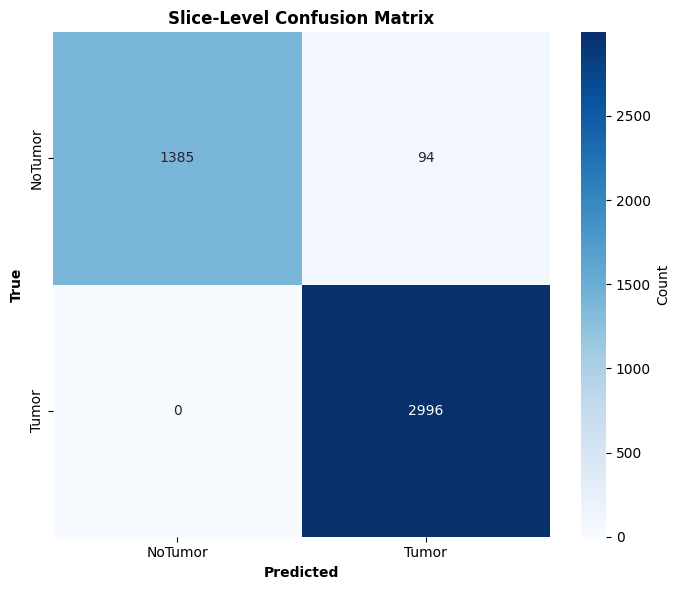

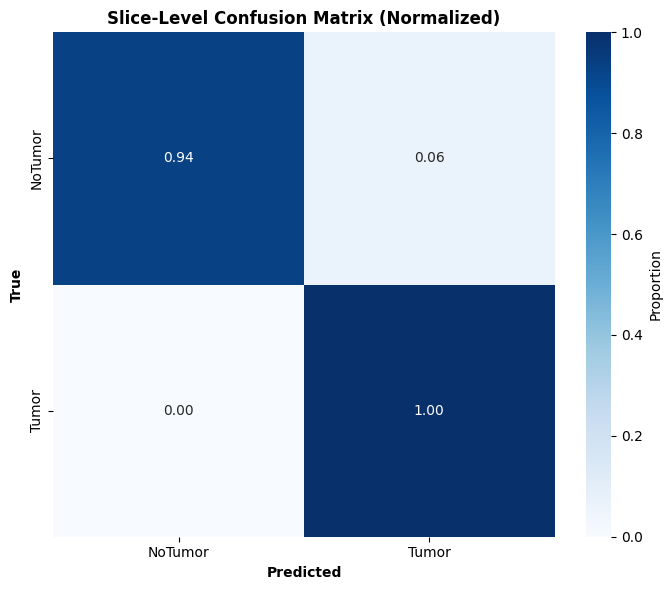


🔹 CASE-LEVEL RESULTS (Majority Voting)
Accuracy: 98.84%

              precision    recall  f1-score   support

     NoTumor     1.0000    0.9540    0.9765        87
       Tumor     0.9847    1.0000    0.9923       257

    accuracy                         0.9884       344
   macro avg     0.9923    0.9770    0.9844       344
weighted avg     0.9886    0.9884    0.9883       344



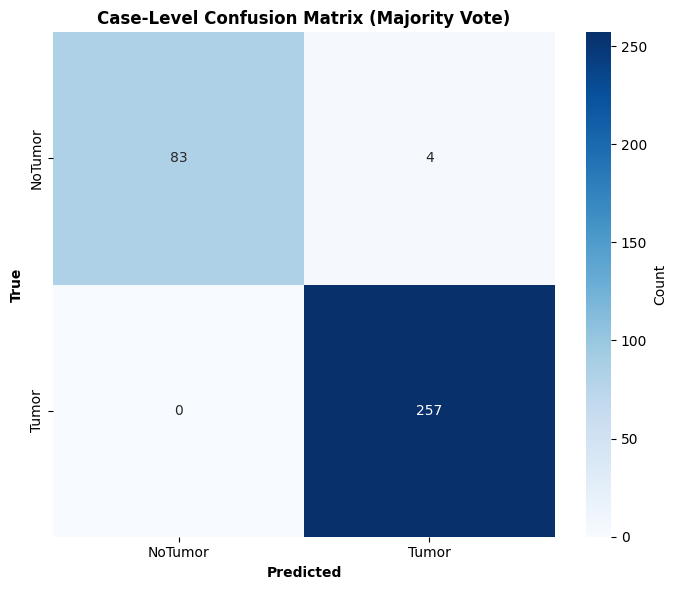

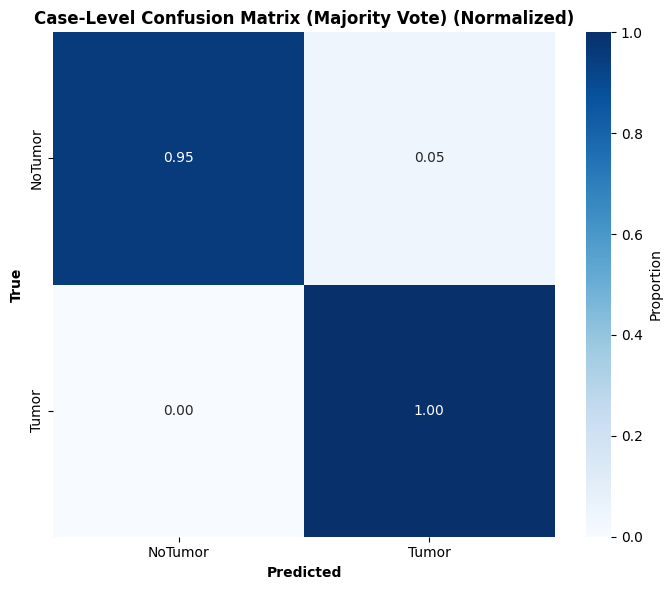


🔹 CASE-LEVEL RESULTS (Mean Tumor Probability)
Accuracy: 98.84%
ROC-AUC : 1.0000

              precision    recall  f1-score   support

     NoTumor     1.0000    0.9540    0.9765        87
       Tumor     0.9847    1.0000    0.9923       257

    accuracy                         0.9884       344
   macro avg     0.9923    0.9770    0.9844       344
weighted avg     0.9886    0.9884    0.9883       344



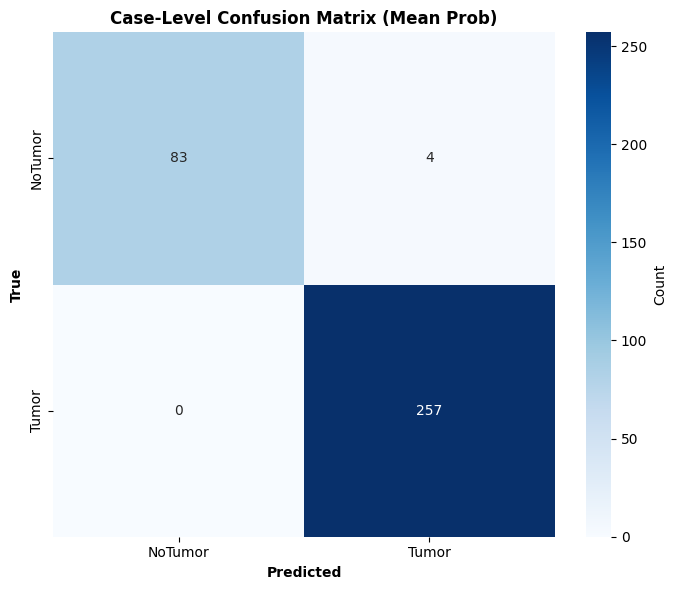

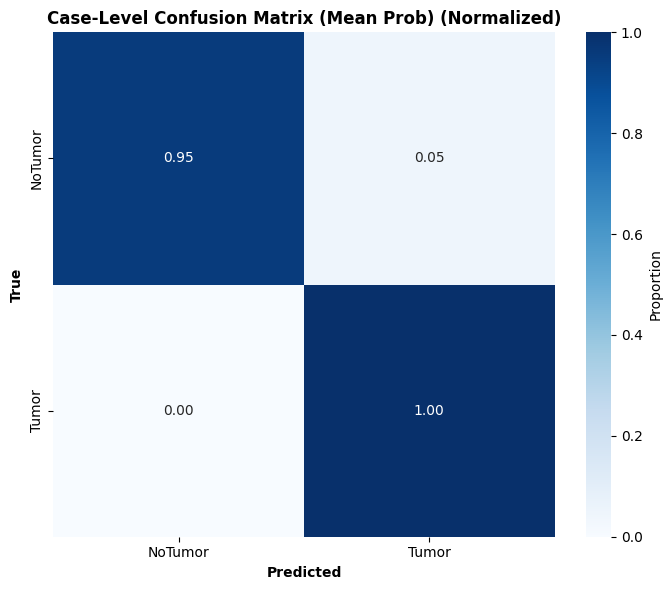

In [26]:
# Cell 17 — Evaluate slice-level + case-level (majority vote + mean prob)

print("=" * 70)
print("📊 EVALUATION: Custom CNN — Tumor vs NoTumor")
print("=" * 70)
CLASS_NAMES = ["NoTumor", "Tumor"]

y_true_slice, y_pred_slice, tumor_prob_slice, case_keys = predict_with_metadata(model, test_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%")
print(f"ROC-AUC : {roc_auc_score(y_true_slice, tumor_prob_slice):.4f}\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix", normalize=True)

y_true_case_vote, y_pred_case_vote = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (Majority Voting)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case_vote, y_pred_case_vote)*100:.2f}%\n")
print(classification_report(y_true_case_vote, y_pred_case_vote, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case_vote, y_pred_case_vote, "Case-Level Confusion Matrix (Majority Vote)", normalize=False)
plot_cm(y_true_case_vote, y_pred_case_vote, "Case-Level Confusion Matrix (Majority Vote)", normalize=True)

y_true_case_mean, y_pred_case_mean, prob_case_mean = case_level_meanprob(
    tumor_prob_slice, case_keys, clean_case_index, threshold=0.5
)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (Mean Tumor Probability)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case_mean, y_pred_case_mean)*100:.2f}%")
print(f"ROC-AUC : {roc_auc_score(y_true_case_mean, prob_case_mean):.4f}\n")
print(classification_report(y_true_case_mean, y_pred_case_mean, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case_mean, y_pred_case_mean, "Case-Level Confusion Matrix (Mean Prob)", normalize=False)
plot_cm(y_true_case_mean, y_pred_case_mean, "Case-Level Confusion Matrix (Mean Prob)", normalize=True)


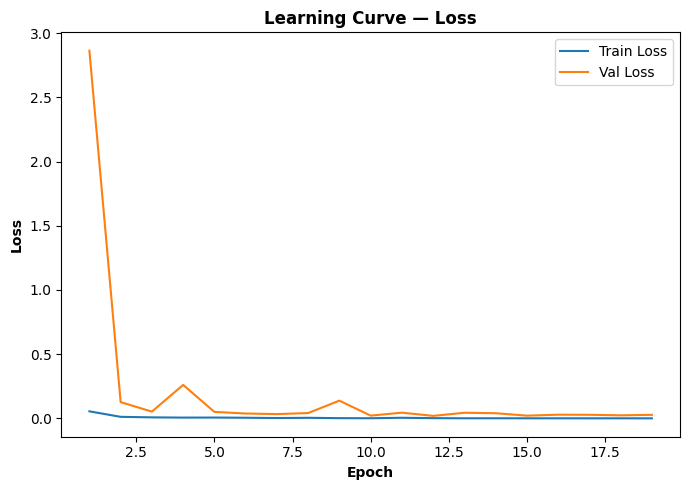

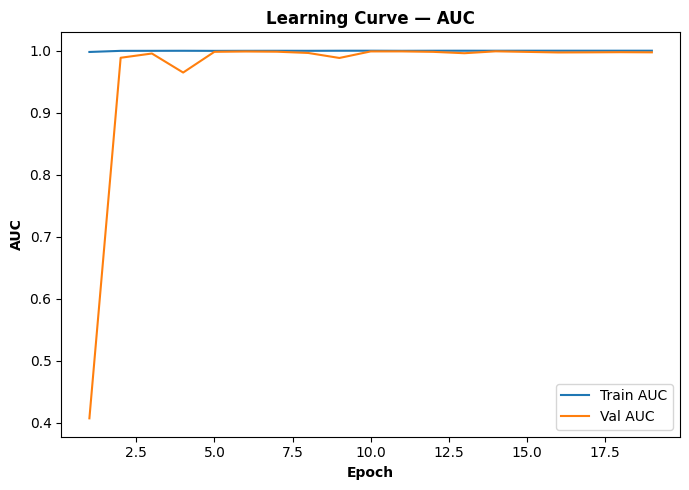

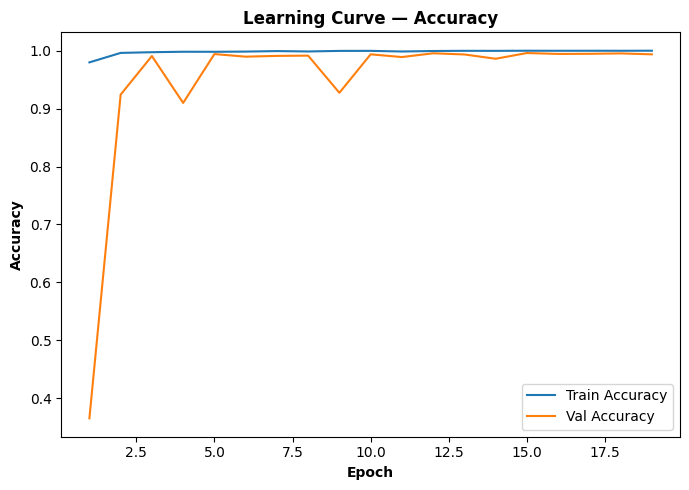

In [27]:
# Cell 18 — Learning curves (Loss / AUC / Accuracy)

hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

def plot_curve(train_key, val_key, title, ylabel):
    if train_key not in hist or val_key not in hist:
        print(f"Skipping {title} (missing {train_key}/{val_key}). Keys:", list(hist.keys()))
        return
    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist[train_key], label=f"Train {ylabel}")
    plt.plot(epochs, hist[val_key], label=f"Val {ylabel}")
    plt.title(title, fontweight="bold")
    plt.xlabel("Epoch", fontweight="bold")
    plt.ylabel(ylabel, fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_curve("loss", "val_loss", "Learning Curve — Loss", "Loss")
plot_curve("auc", "val_auc", "Learning Curve — AUC", "AUC")

if "acc" in hist and "val_acc" in hist:
    plot_curve("acc", "val_acc", "Learning Curve — Accuracy", "Accuracy")
elif "categorical_accuracy" in hist and "val_categorical_accuracy" in hist:
    plot_curve("categorical_accuracy", "val_categorical_accuracy", "Learning Curve — Accuracy", "Accuracy")
else:
    print("Accuracy keys not found. Keys:", list(hist.keys()))


# Fine tuning 

In [28]:
# # Cell FT1 — Build the same Custom CNN but with reduced dropout

def build_custom_cnn_low_dropout(input_shape=(240, 240, 2), base_filters=32,
                                 stage_dropouts=(0.02, 0.05, 0.08, 0.10),
                                 head_dropouts=(0.25, 0.10)):
    inp = layers.Input(shape=input_shape, name="input")

    x = conv_stage(inp, base_filters,     blocks=2, dropout=stage_dropouts[0], name="stage1")
    x = conv_stage(x,   base_filters*2,   blocks=2, dropout=stage_dropouts[1], name="stage2")
    x = conv_stage(x,   base_filters*4,   blocks=3, dropout=stage_dropouts[2], name="stage3")
    x = conv_stage(x,   base_filters*8,   blocks=3, dropout=stage_dropouts[3], name="stage4")

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(256, activation="relu", name="dense1")(x)
    x = layers.Dropout(head_dropouts[0], name="head_drop1")(x)
    x = layers.Dense(64, activation="relu", name="dense2")(x)
    x = layers.Dropout(head_dropouts[1], name="head_drop2")(x)

    out = layers.Dense(2, activation="softmax", name="softmax")(x)
    return models.Model(inp, out, name="CustomCNN_TumorVsNoTumor_LowDropout")

model_ft = build_custom_cnn_low_dropout(input_shape=(IMG_HEIGHT, IMG_WIDTH, 2), base_filters=32)
model_ft.summary()


Model: "CustomCNN_TumorVsNoTumor_LowDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 240, 240, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_conv1 (Conv2D)           │ (None, 240, 240, 32)   │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_bn1 (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_relu1 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_drop1 (Dropout)          │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_conv2 (Conv2D)           │ (None, 240, 240, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_bn2 (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_relu2 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_drop2 (Dropout)          │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_pool (MaxPooling2D)      │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_conv1 (Conv2D)           │ (None, 120, 120, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_bn1 (BatchNormalization) │ (None, 120, 120, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_relu1 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_drop1 (Dropout)          │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_conv2 (Conv2D)           │ (None, 120, 120, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_bn2 (BatchNormalization) │ (None, 120, 120, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_relu2 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_drop2 (Dropout)          │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_pool (MaxPooling2D)      │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_conv1 (Conv2D)           │ (None, 60, 60, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_bn1 (BatchNormalization) │ (None, 60, 60, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_relu1 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_drop1 (Dropout)          │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_conv2 (Conv2D)           │ (None, 60, 60, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_bn2 (BatchNormalization) │ (None, 60, 60, 128)    │           51

 Total params: 1,996,034 (7.61 MB)

 Trainable params: 1,993,346 (7.60 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [29]:
# Cell FT2 — Load the best weights from your previous training into the new model (optional but recommended)

# If you saved best model as "custom_cnn_best.keras" in your callbacks:
model_ft.load_weights("custom_cnn_best.keras")
print("Loaded weights from custom_cnn_best.keras")


Loaded weights from custom_cnn_best.keras


In [30]:
# Cell FT3 — Compile with a smaller learning rate for fine-tuning

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),  # smaller LR for fine tuning
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)


In [31]:
# Cell FT4 — Fine-tune for a few epochs (small tuning)

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(
        "custom_cnn_lowdrop_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

history_ft = model_ft.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,              # small fine-tuning
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/8
874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - acc: 0.9997 - auc: 0.9999 - loss: 0.0010
Epoch 1: val_auc improved from -inf to 0.99931, saving model to custom_cnn_lowdrop_best.keras
874/874 ━━━━━━━━━━━━━━━━━━━━ 154s 157ms/step - acc: 0.9997 - auc: 0.9999 - loss: 0.0010 - val_acc: 0.9978 - val_auc: 0.9993 - val_loss: 0.0091 - learning_rate: 5.0000e-05
Epoch 2/8
874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 1.0000 - auc: 1.0000 - loss: 2.9803e-05
Epoch 2: val_auc did not improve from 0.99931

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
874/874 ━━━━━━━━━━━━━━━━━━━━ 111s 127ms/step - acc: 1.0000 - auc: 1.0000 - loss: 2.9804e-05 - val_acc: 0.9966 - val_auc: 0.9975 - val_loss: 0.0212 - learning_rate: 5.0000e-05
Epoch 3/8
874/874 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - acc: 0.9998 - auc: 0.9999 - loss: 7.4709e-04
Epoch 3: val_auc did not improve from 0.99931

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
874/874 ━━━━━━━━━━

📊 EVALUATION: Fine-tuned Custom CNN (Reduced Dropout)
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step

SLICE-LEVEL:
Accuracy: 100.00%
ROC-AUC : 1.0000

              precision    recall  f1-score   support

     NoTumor     1.0000    1.0000    1.0000      1479
       Tumor     1.0000    1.0000    1.0000      2996

    accuracy                         1.0000      4475
   macro avg     1.0000    1.0000    1.0000      4475
weighted avg     1.0000    1.0000    1.0000      4475



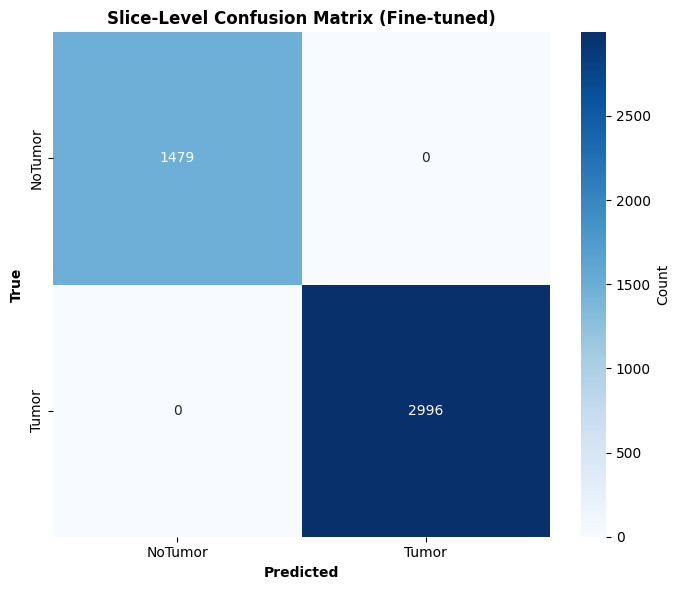

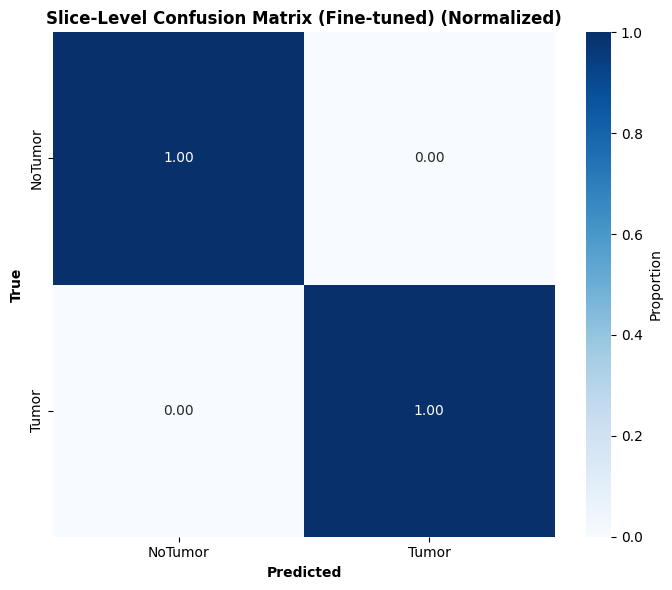


CASE-LEVEL (Majority Vote):
Accuracy: 100.00%

              precision    recall  f1-score   support

     NoTumor     1.0000    1.0000    1.0000        87
       Tumor     1.0000    1.0000    1.0000       257

    accuracy                         1.0000       344
   macro avg     1.0000    1.0000    1.0000       344
weighted avg     1.0000    1.0000    1.0000       344



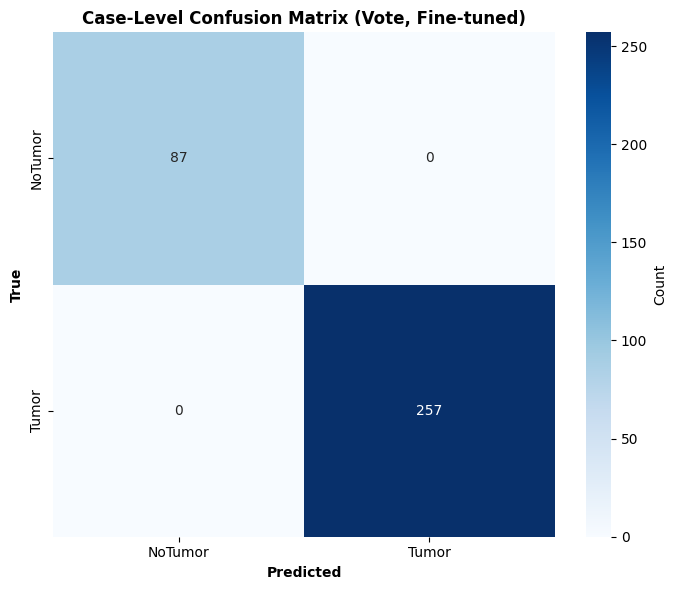

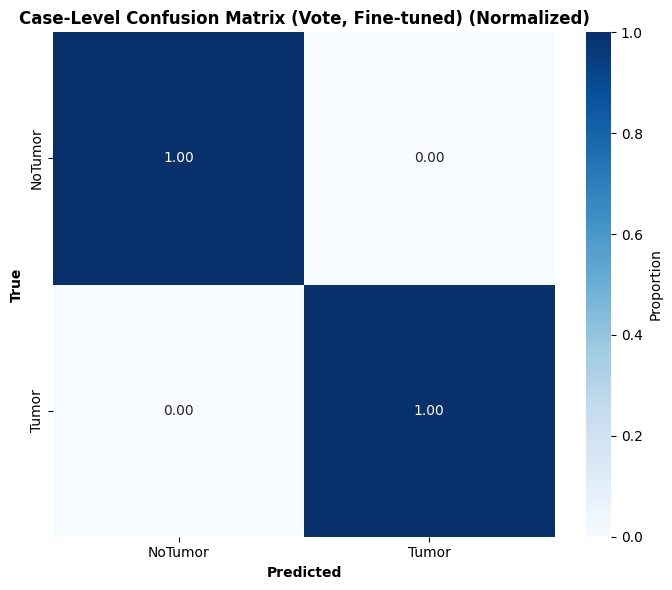


CASE-LEVEL (Mean Prob):
Accuracy: 100.00%
ROC-AUC : 1.0000

              precision    recall  f1-score   support

     NoTumor     1.0000    1.0000    1.0000        87
       Tumor     1.0000    1.0000    1.0000       257

    accuracy                         1.0000       344
   macro avg     1.0000    1.0000    1.0000       344
weighted avg     1.0000    1.0000    1.0000       344



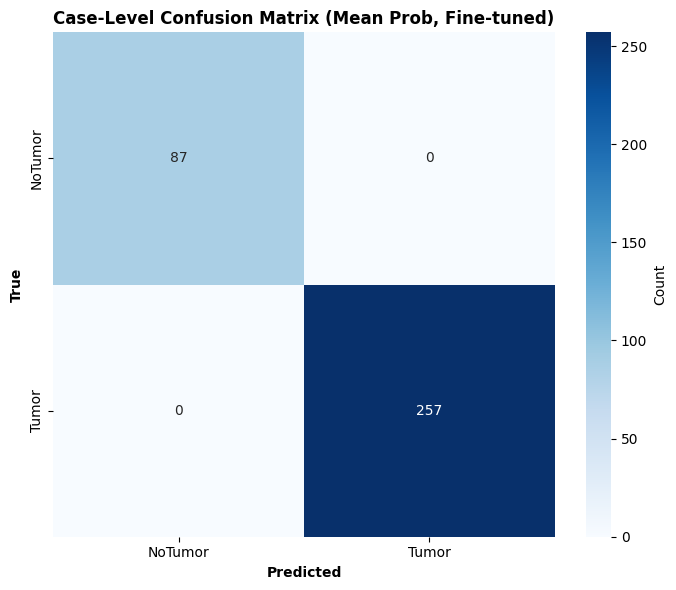

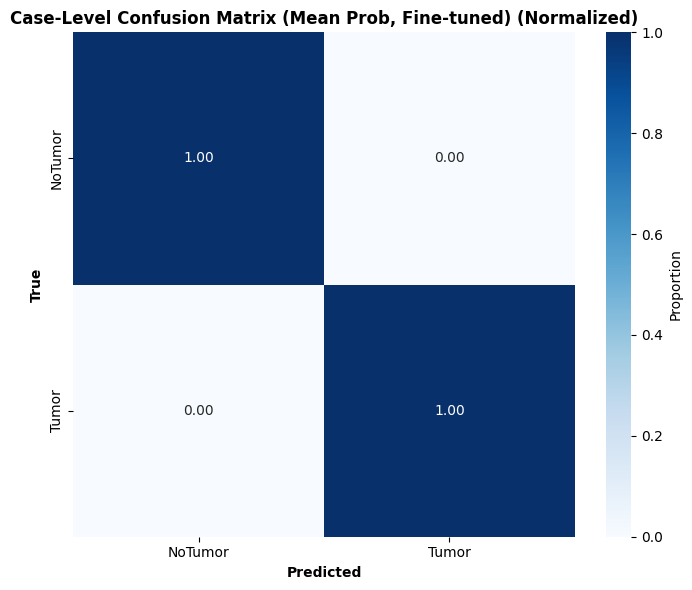

In [32]:
# Cell FT5 — Evaluate fine-tuned model (re-use your evaluation cell)

print("=" * 70)
print("📊 EVALUATION: Fine-tuned Custom CNN (Reduced Dropout)")
print("=" * 70)

y_true_slice, y_pred_slice, tumor_prob_slice, case_keys = predict_with_metadata(model_ft, test_gen)

print("\nSLICE-LEVEL:")
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%")
print(f"ROC-AUC : {roc_auc_score(y_true_slice, tumor_prob_slice):.4f}\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))
plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Fine-tuned)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Fine-tuned)", normalize=True)

y_true_case_vote, y_pred_case_vote = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\nCASE-LEVEL (Majority Vote):")
print(f"Accuracy: {accuracy_score(y_true_case_vote, y_pred_case_vote)*100:.2f}%\n")
print(classification_report(y_true_case_vote, y_pred_case_vote, target_names=CLASS_NAMES, digits=4))
plot_cm(y_true_case_vote, y_pred_case_vote, "Case-Level Confusion Matrix (Vote, Fine-tuned)", normalize=False)
plot_cm(y_true_case_vote, y_pred_case_vote, "Case-Level Confusion Matrix (Vote, Fine-tuned)", normalize=True)

y_true_case_mean, y_pred_case_mean, prob_case_mean = case_level_meanprob(
    tumor_prob_slice, case_keys, clean_case_index, threshold=0.5
)

print("\nCASE-LEVEL (Mean Prob):")
print(f"Accuracy: {accuracy_score(y_true_case_mean, y_pred_case_mean)*100:.2f}%")
print(f"ROC-AUC : {roc_auc_score(y_true_case_mean, prob_case_mean):.4f}\n")
print(classification_report(y_true_case_mean, y_pred_case_mean, target_names=CLASS_NAMES, digits=4))
plot_cm(y_true_case_mean, y_pred_case_mean, "Case-Level Confusion Matrix (Mean Prob, Fine-tuned)", normalize=False)
plot_cm(y_true_case_mean, y_pred_case_mean, "Case-Level Confusion Matrix (Mean Prob, Fine-tuned)", normalize=True)
